# Case SENTINEL — Stage 1: Baseline Surveillance Validation (Orders Dataset)
**DECODE X | NLD Synapse 2026**

Pipeline: Data Load → Order Concentration Detection → Suspect Validation → Mechanism Classification → Network Analysis → Risk Scoring → Entity Expansion

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import glob
import os
import re
import warnings
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('future.no_silent_downcasting', True)

# ─────────────────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────────────────
ORDERS_XLS_FOLDER  = r'E:\Synapse-BI\04 – Case SENTINEL\Orders'
SUSPECT_ORD_FOLDER = r'E:\Synapse-BI\04 – Case SENTINEL\Suspicious list\Orders'

# ─────────────────────────────────────────────────────────────────────────────
# HELPER — normalise any BUY/SELL representation to 'BUY' or 'SELL'
# ─────────────────────────────────────────────────────────────────────────────
_BUY_TOKENS  = {'B', 'BUY', 'BUY ORDER', '1', 'BUYSIDE', 'BID'}
_SELL_TOKENS = {'S', 'SELL', 'SELL ORDER', '2', 'SELLSIDE', 'ASK', 'OFFER'}

def normalise_side(s):
    """Map any raw BUY/SELL encoding to canonical 'BUY' / 'SELL' / 'UNKNOWN'.
    Accepts a pandas Series (returns a Series) or a scalar string."""
    if isinstance(s, pd.Series):
        upper = s.astype(str).str.strip().str.upper()
        result = pd.Series('UNKNOWN', index=upper.index, dtype=str)
        result[upper.isin(_BUY_TOKENS)]  = 'BUY'
        result[upper.isin(_SELL_TOKENS)] = 'SELL'
        return result
    v = str(s).strip().upper()
    if v in _BUY_TOKENS:  return 'BUY'
    if v in _SELL_TOKENS: return 'SELL'
    return 'UNKNOWN'

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1A — LOAD ORDERS  (XLS files in the Orders folder)
# ─────────────────────────────────────────────────────────────────────────────
MONTH_MAP = {
    'Jan':'JAN','Feb':'FEB','Mar':'MAR','Apr':'APR','May':'MAY','Jun':'JUN',
    'Jul':'JUL','July':'JUL','Aug':'AUG','Sep':'SEP','Oct':'OCT',
    'Nov':'NOV','Dec':'DEC',
}

def parse_order_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    m = re.match(r'^(\d+)_(\d+)_([A-Za-z]+)_(\d{4})', name)
    if m:
        scrip_code = m.group(1)
        day        = m.group(2).zfill(2)
        month_raw  = m.group(3)
        year       = m.group(4)
        month_abbr = MONTH_MAP.get(month_raw.capitalize(), month_raw[:3].upper())
        return scrip_code, f'{year}{month_abbr}{day}'
    return None, None

xls_files  = glob.glob(os.path.join(ORDERS_XLS_FOLDER, '*.xls'))
xls_files += glob.glob(os.path.join(ORDERS_XLS_FOLDER, '*.XLS'))

orders_raw = []
for f in tqdm(xls_files, desc='Loading XLS orders'):
    scrip, date_str = parse_order_filename(f)
    try:
        tmp = pd.read_excel(f, engine='xlrd')
        if not tmp.empty:
            tmp.columns = tmp.columns.str.strip()
            tmp['SCRIP_CODE'] = scrip
            tmp['TRADE_DATE'] = date_str
            orders_raw.append(tmp)
    except Exception as e:
        print(f'  WARN: {os.path.basename(f)} → {e}')

if orders_raw:
    df = pd.concat(orders_raw, ignore_index=True)
    df.columns = df.columns.str.strip()
    print(f'Orders loaded from XLS: {len(df):,} rows | {df["SCRIP_CODE"].nunique()} scrips')
else:
    df = pd.DataFrame()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1B — LOAD SUSPECT ORDER LIST
# ─────────────────────────────────────────────────────────────────────────────
suspect_files = glob.glob(os.path.join(SUSPECT_ORD_FOLDER, '*.csv'))
sus_raw = []
for f in suspect_files:
    try:
        tmp = pd.read_csv(f)
        tmp.columns = tmp.columns.str.strip()
        wanted = [c for c in tmp.columns
                  if c.strip() in ('scrip_code','big_ord_client_id',
                                   'big_ord_member_code','big_order_type','order_id')]
        tmp = tmp[wanted]
        if not tmp.empty:
            fname = os.path.basename(f)
            m = re.match(r'SCRIP_(\d{4}[A-Z]{3}\d{2})_', fname)
            tmp['TRADE_DATE'] = m.group(1) if m else 'UNKNOWN'
            sus_raw.append(tmp)
    except Exception as e:
        print(f'  WARN: {os.path.basename(f)} → {e}')

suspects_df = pd.concat(sus_raw, ignore_index=True)
suspects_df.columns = suspects_df.columns.str.strip()
suspects_df = suspects_df.rename(columns={
    'scrip_code'          : 'SCRIP_CODE',
    'big_ord_client_id'   : 'client_id',
    'big_ord_member_code' : 'member_code',
    'big_order_type'      : 'order_side',
})
suspects_df['SCRIP_CODE']  = suspects_df['SCRIP_CODE'].astype(str).str.strip()
suspects_df['client_id']   = suspects_df['client_id'].astype(str).str.strip()
suspects_df['member_code'] = suspects_df['member_code'].astype(str).str.strip()
suspects_df['order_side']  = normalise_side(suspects_df['order_side'])

print(f"\nSuspect order list: {len(suspects_df):,} rows | "
      f"{suspects_df['client_id'].nunique():,} unique clients | "
      f"{suspects_df['SCRIP_CODE'].nunique()} scrips | "
      f"{suspects_df['TRADE_DATE'].nunique()} dates")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1C — MASTER ORDER TAPE (normalise XLS columns)
# ─────────────────────────────────────────────────────────────────────────────
if not df.empty:
    # ── 1. Pick the best BUY/SELL source column (highest recognisable-token rate)
    _BS_ALIASES = {'order_side', 'buy_sell_flag', 'buy_sell',
                   'side', 'order_type', 'buysell', 'buy_or_sell'}
    bs_candidates = [c for c in df.columns
                     if c.lower().replace(' ', '_').replace('/', '_') in _BS_ALIASES]
    best_bs_col, best_bs_rate = None, -1.0
    for c in bs_candidates:
        vals = df[c].astype(str).str.strip().str.upper()
        rate = vals.isin(_BUY_TOKENS | _SELL_TOKENS).mean()
        print(f"  BS candidate '{c}': recognisable {rate:.1%} | "
              f"sample {vals.value_counts().head(5).to_dict()}")
        if rate > best_bs_rate:
            best_bs_rate = rate
            best_bs_col  = c
    print(f"  → Best BUY/SELL column: '{best_bs_col}' ({best_bs_rate:.1%} recognisable)")

    # ── 2. Build rename map — avoid creating duplicate column names
    col_map = {}
    target_taken = set()        # track targets already assigned
    for c in df.columns:
        cl = c.lower().replace(' ', '_').replace('/', '_')
        target = None
        if   'client' in cl:   target = 'client_id'
        elif 'member' in cl:   target = 'member_code'
        elif cl in _BS_ALIASES:
            # Only rename to 'order_side' for the single best column
            if c == best_bs_col:
                target = 'order_side'
            # else: leave other BUY/SELL-like columns under their original names
        elif 'qty' in cl or 'quantity' in cl or 'qunatity' in cl:
            target = 'ORDER_QTY'
        elif 'price' in cl or 'rate' in cl:
            target = 'ORDER_PRICE'
        elif 'time' in cl and 'date' not in cl:
            target = 'ORDER_TIME'
        elif 'order_id' in cl or 'orderno' in cl or 'order_number' in cl:
            target = 'order_id'

        if target and target not in target_taken and c != target:
            col_map[c]    = target
            target_taken.add(target)

    df = df.rename(columns=col_map)

    # ── 3. If best_bs_col was NOT in rename map (it already had the right name)
    #       but 'order_side' doesn't exist yet, assign it explicitly
    if 'order_side' not in df.columns and best_bs_col and best_bs_col in df.columns:
        df['order_side'] = df[best_bs_col]

    # ── 4. Normalise string fields
    for col in ['client_id', 'member_code', 'SCRIP_CODE', 'TRADE_DATE']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # ── 5. Normalise order_side to canonical 'BUY' / 'SELL'
    if 'order_side' in df.columns:
        df['order_side'] = normalise_side(df['order_side'])
        side_vc = df['order_side'].value_counts().to_dict()
        print(f"\n  order_side after normalisation: {side_vc}")
    else:
        print("\n  [WARNING] No order_side column found — downstream analysis may fail")

print(f"\nMaster order tape (XLS): {len(df):,} rows | "
      f"clients: {df['client_id'].nunique():,} | "
      f"members: {df['member_code'].nunique():,}")
print(f"Columns: {list(df.columns)}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1D — BUILD GRAPHS
# ─────────────────────────────────────────────────────────────────────────────
B_graph = nx.Graph()
mc_edges = df[['member_code', 'client_id']].dropna().drop_duplicates()
members  = set(mc_edges['member_code'])
clients  = set(mc_edges['client_id'])
B_graph.add_nodes_from(members, bipartite=0, node_type='Member')
B_graph.add_nodes_from(clients,  bipartite=1, node_type='Client')
B_graph.add_edges_from(mc_edges.values)

MC_DG = nx.DiGraph()
for _, row in mc_edges.iterrows():
    if MC_DG.has_edge(row['member_code'], row['client_id']):
        MC_DG[row['member_code']][row['client_id']]['weight'] += 1
    else:
        MC_DG.add_edge(row['member_code'], row['client_id'], weight=1)

print(f"\nBipartite graph  : {B_graph.number_of_nodes():,} nodes | {B_graph.number_of_edges():,} edges")
print(f"Directed MC graph: {MC_DG.number_of_nodes():,} nodes | {MC_DG.number_of_edges():,} edges")

Loading XLS orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders loaded from XLS: 1,294,422 rows | 3 scrips

Suspect order list: 1,852 rows | 85 unique clients | 5 scrips | 7 dates
  BS candidate 'Order Type': recognisable 0.0% | sample {'L': 1283110, 'P': 7992, 'M': 3200, 'O': 100, 'T': 16}
  BS candidate 'Buy/Sell Flag': recognisable 100.0% | sample {'S': 661264, 'B': 633158}
  → Best BUY/SELL column: 'Buy/Sell Flag' (100.0% recognisable)

  order_side after normalisation: {'SELL': 661264, 'BUY': 633158}

Master order tape (XLS): 1,294,422 rows | clients: 49,933 | members: 592
Columns: ['Scrip Code', 'order_id', 'ORDER_DATE', 'ORDER_TIME', 'member_code', 'client_id', 'ORDER_QTY', 'value', 'Order Type', 'Terminal No', 'order_side', 'Location Id', 'SCRIP_CODE', 'TRADE_DATE']

Bipartite graph  : 50,470 nodes | 52,468 edges
Directed MC graph: 50,470 nodes | 52,468 edges


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — ORDER CONCENTRATION DETECTION
# (analogous to Loop Detection in the trades notebook)
#
# Detects clients with concentrated one-sided order activity per scrip/date.
# Also flags "wash-order" clients who appear on BOTH BUY and SELL sides
# in the same scrip/date session (equivalent to loop reciprocity in trades).
# ─────────────────────────────────────────────────────────────────────────────

# Explicit column schema so we always get a typed DataFrame even when empty
_PATTERN_COLS = {
    'SCRIP_CODE'            : 'object',
    'TRADE_DATE'            : 'object',
    'client_id'             : 'object',
    'n_buy_orders'          : 'int64',
    'n_sell_orders'         : 'int64',
    'total_orders'          : 'int64',
    'buy_qty'               : 'float64',
    'sell_qty'              : 'float64',
    'order_imbalance'       : 'float64',
    'time_span_sec'         : 'float64',
    'concentration_pattern' : 'object',
}

def detect_order_concentration(df_input, min_orders=1):
    """
    Detect one-sided order concentration patterns per client per scrip per date.
    Returns one row per (client, scrip, date) with side counts and a pattern flag.

    min_orders=1  → every client with any order is captured (suspect list entries
    typically record one flagged order per session, so ≥2 would filter everything).
    """
    all_patterns = []

    has_qty  = 'ORDER_QTY'  in df_input.columns
    has_time = 'ORDER_TIME' in df_input.columns

    grp_cols = ['SCRIP_CODE', 'TRADE_DATE', 'client_id']
    for (scrip, date, client), grp in tqdm(df_input.groupby(grp_cols),
                                           desc='Detecting concentrations',
                                           leave=False):
        buy_rows  = grp[grp['order_side'] == 'BUY']
        sell_rows = grp[grp['order_side'] == 'SELL']
        n_buy  = len(buy_rows)
        n_sell = len(sell_rows)
        total  = n_buy + n_sell

        if total < min_orders:
            continue

        buy_qty  = buy_rows['ORDER_QTY'].sum()  if has_qty else np.nan
        sell_qty = sell_rows['ORDER_QTY'].sum() if has_qty else np.nan

        span_s = np.nan
        if has_time:
            times = pd.to_datetime(grp['ORDER_TIME'], errors='coerce').dropna().sort_values()
            if len(times) >= 2:
                span_s = (times.iloc[-1] - times.iloc[0]).total_seconds()

        # Pattern classification
        if n_buy > 0 and n_sell > 0:
            pattern = 'WASH_ORDER'
        elif n_buy > 0:
            pattern = 'BUY_CONCENTRATION'
        elif n_sell > 0:
            pattern = 'SELL_CONCENTRATION'
        else:
            pattern = 'SINGLE_ORDER'

        imbalance = abs(n_buy - n_sell) / (total + 1e-9)

        all_patterns.append({
            'SCRIP_CODE'            : scrip,
            'TRADE_DATE'            : date,
            'client_id'             : client,
            'n_buy_orders'          : n_buy,
            'n_sell_orders'         : n_sell,
            'total_orders'          : total,
            'buy_qty'               : buy_qty,
            'sell_qty'              : sell_qty,
            'order_imbalance'       : imbalance,
            'time_span_sec'         : span_s,
            'concentration_pattern' : pattern,
        })

    if not all_patterns:
        # Return typed empty DataFrame — prevents KeyError downstream
        return pd.DataFrame({c: pd.Series(dtype=t)
                              for c, t in _PATTERN_COLS.items()})
    return pd.DataFrame(all_patterns)


order_patterns_df = detect_order_concentration(df, min_orders=1)

# ── Summary ───────────────────────────────────────────────────────────────────
pat_counts = order_patterns_df['concentration_pattern'].value_counts()
print(f"\n{'='*60}")
print(f"  Total concentration patterns detected : {len(order_patterns_df):,}")
print(f"{'─'*60}")
for pat, cnt in pat_counts.items():
    pct = cnt / len(order_patterns_df) * 100 if len(order_patterns_df) else 0
    print(f"  {pat:<30} {cnt:>6,}   ({pct:.1f}%)")
print(f"  {'─'*55}")
print(f"  Unique clients in patterns : {order_patterns_df['client_id'].nunique():,}")
print(f"  Scrips with patterns       : {order_patterns_df['SCRIP_CODE'].nunique()}")
print(f"  Dates with patterns        : {order_patterns_df['TRADE_DATE'].nunique()}")
print(f"{'='*60}")
order_patterns_df.head(5)

Detecting concentrations:   0%|          | 0/61548 [00:00<?, ?it/s]


  Total concentration patterns detected : 61,548
────────────────────────────────────────────────────────────
  WASH_ORDER                     34,316   (55.8%)
  SELL_CONCENTRATION             18,364   (29.8%)
  BUY_CONCENTRATION               8,868   (14.4%)
  ───────────────────────────────────────────────────────
  Unique clients in patterns : 49,933
  Scrips with patterns       : 3
  Dates with patterns        : 5


,SCRIP_CODE,TRADE_DATE,client_id,n_buy_orders,n_sell_orders,total_orders,buy_qty,sell_qty,order_imbalance,time_span_sec,concentration_pattern
0,554412,2007APR13,13072D,0,2,2,0,20,1.0,0.000000,SELL_CONCENTRATION
1,554412,2007APR13,1490,0,6,6,0,5000,1.0,2767.239858,SELL_CONCENTRATION
2,554412,2007APR13,1500012202,0,2,2,0,240,1.0,0.000000,SELL_CONCENTRATION
3,554412,2007APR13,1500607337,2,0,2,160,0,1.0,0.000000,BUY_CONCENTRATION
4,554412,2007APR13,15M68,0,2,2,0,100,1.0,0.000000,SELL_CONCENTRATION


## Task 1 — Validate Suspected Entities (Orders)
Cross-reference the suspect order list against the detected order concentration patterns.  
Classify each suspect as **CONFIRMED**, **PARTIAL**, or **INSUFFICIENT EVIDENCE**.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1 — Validate Suspected Entities (Orders)
# ─────────────────────────────────────────────────────────────────────────────

# 1a. Per-client pattern statistics (client-level, across all scrips)
pat_stats = (order_patterns_df
             .groupby('client_id', as_index=False)
             .agg(
                 pattern_count      = ('SCRIP_CODE', 'count'),
                 scrips_involved    = ('SCRIP_CODE', 'nunique'),
                 dates_involved     = ('TRADE_DATE', 'nunique'),
                 total_orders       = ('total_orders', 'sum'),
                 wash_patterns      = ('concentration_pattern',
                                       lambda x: (x == 'WASH_ORDER').sum()),
                 avg_imbalance      = ('order_imbalance', 'mean'),
                 avg_time_span      = ('time_span_sec', 'mean'),
             ))

# 1b. Order-side balance per client (BUY vol vs SELL vol)
buy_grp  = df[df['order_side'] == 'BUY'].groupby('client_id').size().rename('n_buy_total')
sell_grp = df[df['order_side'] == 'SELL'].groupby('client_id').size().rename('n_sell_total')
side_df  = pd.DataFrame({'n_buy_total': buy_grp, 'n_sell_total': sell_grp}).fillna(0)
side_df.index = side_df.index.astype(str).str.strip()
side_df['reciprocity_ratio'] = (
    side_df[['n_buy_total','n_sell_total']].min(axis=1) /
    (side_df[['n_buy_total','n_sell_total']].max(axis=1) + 1e-9)
)

# 1c. Counterparty diversity: unique members a client uses
cp_mem = df.groupby('client_id')['member_code'].nunique().rename('unique_members')
cp_mem.index = cp_mem.index.astype(str).str.strip()

# 1d. Merge onto the suspect list (one row per unique client_id)
val = suspects_df[['client_id']].drop_duplicates().copy()
val['client_id'] = val['client_id'].astype(str).str.strip()

val = val.merge(pat_stats, on='client_id', how='left')
val = val.merge(side_df[['reciprocity_ratio']],
                left_on='client_id', right_index=True, how='left')
val = val.merge(cp_mem.reset_index().rename(columns={'client_id':'client_id'}),
                on='client_id', how='left')

# Fill missing
for col in ['pattern_count','scrips_involved','dates_involved','total_orders',
            'wash_patterns','avg_imbalance','reciprocity_ratio','unique_members']:
    val[col] = val[col].fillna(0).infer_objects(copy=False)

# 1e. Classification rules
#   CONFIRMED  : ≥ 3 patterns AND reciprocity ≥ 0.5 (significant bilateral order activity)
#   PARTIAL    : appeared in ≥ 1 pattern
#   INSUFFICIENT EVIDENCE : no pattern
def classify_suspect(row):
    if row['pattern_count'] >= 3 and row['reciprocity_ratio'] >= 0.5:
        return 'CONFIRMED'
    if row['pattern_count'] >= 1:
        return 'PARTIAL'
    return 'INSUFFICIENT EVIDENCE'

val['validation_status'] = val.apply(classify_suspect, axis=1)

# ── Summary ───────────────────────────────────────────────────────────────────
counts = val['validation_status'].value_counts()
print("=" * 55)
print(f"  TASK 1 — ENTITY VALIDATION RESULTS (ORDERS)")
print("=" * 55)
for status, cnt in counts.items():
    pct = cnt / len(val) * 100
    print(f"  {status:<25} {cnt:>5,}   ({pct:.1f}%)")
print(f"  {'─'*48}")
print(f"  Total unique suspects assessed: {len(val):>5,}")
print("=" * 55)

confirmed = val[val['validation_status'] == 'CONFIRMED']
print(f"\nTop 10 CONFIRMED clients by pattern count:")
print(confirmed.sort_values('pattern_count', ascending=False)
      [['client_id','pattern_count','dates_involved','total_orders',
        'reciprocity_ratio']].head(10).to_string(index=False))

validation = val.copy()   # keep for downstream tasks

  TASK 1 — ENTITY VALIDATION RESULTS (ORDERS)
  PARTIAL                      55   (64.7%)
  INSUFFICIENT EVIDENCE        25   (29.4%)
  CONFIRMED                     5   (5.9%)
  ────────────────────────────────────────────────
  Total unique suspects assessed:    85

Top 10 CONFIRMED clients by pattern count:
client_id  pattern_count  dates_involved  total_orders  reciprocity_ratio
    L16WN           15.0             5.0      159880.0           0.941139
 J18RJP09            4.0             4.0         116.0           0.657143
      nan            4.0             3.0         148.0           0.897436
  Z1IK001            3.0             3.0          20.0           0.666667
   N14002            3.0             3.0         124.0           0.631579


## Task 2 — Classify Manipulation Mechanism & Client-Level Suspicion (Orders)

Classify each detected order concentration pattern as one of four manipulation types, then map every client to either **Non-Suspicious** or the specific reason they are suspicious (**Wash Trading**, **Layering**, **Infrastructure-Linked**, or **Infrastructure-Linked Layering**).

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 — Classify Manipulation Mechanism (Orders)
# ─────────────────────────────────────────────────────────────────────────────

patterns_full = order_patterns_df.copy()

# 2a. Infrastructure overlap — vectorised (no row-by-row apply)
#     A session (SCRIP_CODE, TRADE_DATE) is "infra-linked" if any single member
#     served ≥ 2 distinct clients in that session.
session_member_clients = (
    df.groupby(['SCRIP_CODE', 'TRADE_DATE', 'member_code'])['client_id']
      .nunique()
      .reset_index(name='n_clients')
)
infra_sessions = (
    session_member_clients[session_member_clients['n_clients'] >= 2]
    [['SCRIP_CODE', 'TRADE_DATE']]
    .drop_duplicates()
    .assign(infra_linked=True)
)
patterns_full = patterns_full.merge(infra_sessions, on=['SCRIP_CODE', 'TRADE_DATE'], how='left')
patterns_full['infra_linked'] = patterns_full['infra_linked'].fillna(False)

infra_pct = patterns_full['infra_linked'].mean() * 100
print(f"Infra-linked sessions: {infra_sessions['SCRIP_CODE'].count():,} | "
      f"{infra_pct:.1f}% of patterns flagged as infra-linked")

# 2b. Classify mechanism
LAYERING_THRESHOLD = 0.80

def classify_mechanism(row):
    is_infra    = bool(row['infra_linked'])
    is_layering = row['order_imbalance'] >= LAYERING_THRESHOLD
    is_wash     = row['concentration_pattern'] == 'WASH_ORDER'

    if is_wash:
        return 'Infrastructure-Linked Wash Trading' if is_infra else 'Wash Trading'
    if is_infra and is_layering:
        return 'Infrastructure-Linked Layering'
    if is_infra:
        return 'Infrastructure-Linked'
    if is_layering:
        return 'Layering'
    return 'Order Concentration'

patterns_full['mechanism'] = patterns_full.apply(classify_mechanism, axis=1)

mech_counts = patterns_full['mechanism'].value_counts()
print("=" * 65)
print("  TASK 2 — MECHANISM CLASSIFICATION (ORDERS)")
print("=" * 65)
for mech, cnt in mech_counts.items():
    pct = cnt / len(patterns_full) * 100
    print(f"  {mech:<50} {cnt:>5,}  ({pct:.1f}%)")
print("=" * 65)

# ─────────────────────────────────────────────────────────────────────────────
# 2c. CLIENT-LEVEL CLASSIFICATION
# ─────────────────────────────────────────────────────────────────────────────
SEVERITY = {
    'Infrastructure-Linked Wash Trading': 6,
    'Infrastructure-Linked Layering'    : 5,
    'Wash Trading'                      : 4,
    'Layering'                          : 3,
    'Infrastructure-Linked'             : 2,
    'Order Concentration'               : 1,
}

client_mech = patterns_full[['client_id', 'mechanism']].copy()
client_mech['severity'] = client_mech['mechanism'].map(SEVERITY)
worst_mech = (
    client_mech.sort_values('severity', ascending=False)
               .groupby('client_id', as_index=False)
               .first()[['client_id', 'mechanism']]
               .rename(columns={'mechanism': 'suspicion_reason'})
)

all_clients_df = pd.DataFrame({
    'client_id': df['client_id'].astype(str).str.strip().drop_duplicates().values
})
all_clients_df = all_clients_df.merge(worst_mech, on='client_id', how='left')
all_clients_df['classification'] = all_clients_df['suspicion_reason'].fillna('Non-Suspicious')

class_counts = all_clients_df['classification'].value_counts()
print("\n" + "=" * 65)
print("  TASK 2 — CLIENT-LEVEL CLASSIFICATION (ALL ORDER CLIENTS)")
print("=" * 65)
for cls, cnt in class_counts.items():
    pct = cnt / len(all_clients_df) * 100
    print(f"  {cls:<50} {cnt:>5,}  ({pct:.1f}%)")
print(f"  {'─'*60}")
print(f"  Total unique clients assessed: {len(all_clients_df):>5,}")
print("=" * 65)

# Suspects-only cross-reference
suspect_cls = val[['client_id']].merge(all_clients_df, on='client_id', how='left')
suspect_cls['classification'] = suspect_cls['classification'].fillna('Non-Suspicious')
sus_counts = suspect_cls['classification'].value_counts()
print("\n" + "=" * 65)
print("  TASK 2 — SUSPECT LIST CLASSIFICATION (ORDERS)")
print("=" * 65)
for cls, cnt in sus_counts.items():
    pct = cnt / len(suspect_cls) * 100
    print(f"  {cls:<50} {cnt:>5,}  ({pct:.1f}%)")
print(f"  {'─'*60}")
print(f"  Total suspects classified: {len(suspect_cls):>5,}")
print("=" * 65)
print("\nDetailed suspect classification (first 30):")
print(suspect_cls.sort_values('classification').head(30).to_string(index=False))

task2_classification = suspect_cls.copy()

Infra-linked sessions: 15 | 100.0% of patterns flagged as infra-linked
  TASK 2 — MECHANISM CLASSIFICATION (ORDERS)
  Infrastructure-Linked Wash Trading                 34,316  (55.8%)
  Infrastructure-Linked Layering                     27,232  (44.2%)

  TASK 2 — CLIENT-LEVEL CLASSIFICATION (ALL ORDER CLIENTS)
  Infrastructure-Linked Wash Trading                 28,314  (56.7%)
  Infrastructure-Linked Layering                     21,619  (43.3%)
  ────────────────────────────────────────────────────────────
  Total unique clients assessed: 49,933

  TASK 2 — SUSPECT LIST CLASSIFICATION (ORDERS)
  Infrastructure-Linked Layering                        43  (50.6%)
  Non-Suspicious                                        25  (29.4%)
  Infrastructure-Linked Wash Trading                    17  (20.0%)
  ────────────────────────────────────────────────────────────
  Total suspects classified:    85

Detailed suspect classification (first 30):
 client_id               suspicion_reason        

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 — Value Counts: Client Classification (Orders)
# ─────────────────────────────────────────────────────────────────────────────

print("All clients in order tape")
print("─" * 50)
vc_all = all_clients_df['classification'].value_counts()
vc_all_pct = (vc_all / vc_all.sum() * 100).round(1)
vc_all_df = pd.DataFrame({'Count': vc_all, 'Pct (%)': vc_all_pct})
print(vc_all_df.to_string())
print(f"\nTotal unique clients : {vc_all.sum():,}")

if 'task2_classification' in dir():
    print("\n\nSuspect list only")
    print("─" * 50)
    vc_sus = task2_classification['classification'].value_counts()
    vc_sus_pct = (vc_sus / vc_sus.sum() * 100).round(1)
    vc_sus_df = pd.DataFrame({'Count': vc_sus, 'Pct (%)': vc_sus_pct})
    print(vc_sus_df.to_string())
    print(f"\nTotal suspects classified : {vc_sus.sum():,}")

All clients in order tape
──────────────────────────────────────────────────
                                    Count  Pct (%)
classification                                    
Infrastructure-Linked Wash Trading  28314     56.7
Infrastructure-Linked Layering      21619     43.3

Total unique clients : 49,933


Suspect list only
──────────────────────────────────────────────────
                                    Count  Pct (%)
classification                                    
Infrastructure-Linked Layering         43     50.6
Non-Suspicious                         25     29.4
Infrastructure-Linked Wash Trading     17     20.0

Total suspects classified : 85


## Task 3 — Network Analysis (Orders)
Order-side balance, member-client linkages, order synchronisation, and motif distribution across detected order patterns.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3 — Network Analysis (Orders)
# ─────────────────────────────────────────────────────────────────────────────

# 3a. Bilateral order clients: clients who appear on BOTH BUY and SELL sides
buy_clients  = set(df[df['order_side'] == 'BUY']['client_id'].astype(str).str.strip())
sell_clients = set(df[df['order_side'] == 'SELL']['client_id'].astype(str).str.strip())
bilateral_clients = buy_clients.intersection(sell_clients)
print(f"Bilateral clients (appear on both BUY and SELL sides): {len(bilateral_clients):,}")

# 3b. Order-side balance: |n_buy - n_sell| / max < 10%  ⟹ balanced
side_bal = side_df.copy()
side_bal['balanced'] = (
    abs(side_bal['n_buy_total'] - side_bal['n_sell_total']) /
    (side_bal[['n_buy_total','n_sell_total']].max(axis=1) + 1e-9)
) < 0.10
print(f"Perfectly balanced order clients (diff <10%)        : {side_bal['balanced'].sum():,}")

# 3c. Member–client linkage statistics
mc_long = (pd.concat([
    df[['member_code','client_id']].copy()
]).drop_duplicates())
mc_long['member_code'] = mc_long['member_code'].astype(str).str.strip()
mc_long['client_id']   = mc_long['client_id'].astype(str).str.strip()

member_stats = (mc_long.groupby('member_code', as_index=False)
                .agg(client_count=('client_id', 'nunique')))
member_stats = member_stats.sort_values('client_count', ascending=False)

print(f"\nTop 10 members by client count in orders:")
print(member_stats.head(10).to_string(index=False))

# 3d. Order synchronisation: average inter-order gap per pattern (if time available)
patterns_full['avg_gap_sec'] = (
    patterns_full['time_span_sec'] /
    (patterns_full['total_orders'] - 1).clip(lower=1)
)

if patterns_full['avg_gap_sec'].notna().sum() > 0:
    synced = (patterns_full['avg_gap_sec'].dropna() < 60).sum()
    print(f"\nPatterns with avg inter-order gap < 60s (rapid fire): {synced:,} / "
          f"{patterns_full['avg_gap_sec'].notna().sum():,}")
    print(f"Overall median avg gap (seconds): "
          f"{patterns_full['avg_gap_sec'].median():.1f}")
else:
    print("\n[No order timestamp data available for gap analysis]")

# 3e. Pattern motif stats per scrip
motif_stats = (patterns_full.groupby(['SCRIP_CODE', 'concentration_pattern'])
               .agg(count=('total_orders', 'count'),
                    avg_orders=('total_orders', 'mean'),
                    avg_imbalance=('order_imbalance', 'mean'))
               .reset_index())
print(f"\nMotif distribution by scrip:")
print(motif_stats.to_string(index=False))

Bilateral clients (appear on both BUY and SELL sides): 28,742
Perfectly balanced order clients (diff <10%)        : 6,888

Top 10 members by client count in orders:
member_code  client_count
        635          4312
        469          2305
         53          1588
         50          1570
        316          1223
        771          1220
        933          1184
         26           983
        281           981
        276           938

Patterns with avg inter-order gap < 60s (rapid fire): 24,310 / 61,548
Overall median avg gap (seconds): 155.7

Motif distribution by scrip:
SCRIP_CODE concentration_pattern  count  avg_orders  avg_imbalance
    554412     BUY_CONCENTRATION    476    3.407563       1.000000
    554412    SELL_CONCENTRATION    863    3.492468       1.000000
    554412            WASH_ORDER    402   18.626866       0.299472
    555835     BUY_CONCENTRATION    480    3.750000       1.000000
    555835    SELL_CONCENTRATION   1542    3.066148       1.000000
    55

## Task 4 — Risk Scoring (Orders)
Compute composite risk scores (0–100) for each client and member using 5 evidence signals derived from order behaviour.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4 — Risk Scoring  (Client + Member)  — Orders
#
# Signal weights (sum = 100):
#   S1  30  Pattern participation — normalised by most active client
#   S2  25  Reciprocity ratio (bilateral BUY/SELL activity)
#   S3  20  Member concentration: 1/(unique_members+1) — fewer members → riskier
#   S4  15  Order volume dominance — relative to max across all clients
#   S5  10  Rapid-fire flag — avg gap < 60s
# ─────────────────────────────────────────────────────────────────────────────

W = dict(S1=30, S2=25, S3=20, S4=15, S5=10)

# ── CLIENT SIGNALS ─────────────────────────────────────────────────────────────

# S1: Pattern participation — normalised
s1 = pat_stats[['client_id', 'pattern_count']].copy()
s1['S1'] = (s1['pattern_count'] / (s1['pattern_count'].max() + 1e-9)).clip(0, 1)

# S2: Reciprocity ratio (already 0–1)
s2 = side_df[['reciprocity_ratio']].copy().reset_index()
s2.columns = ['client_id', 'reciprocity_ratio']
s2['client_id'] = s2['client_id'].astype(str).str.strip()
s2['S2'] = s2['reciprocity_ratio'].clip(0, 1)

# S3: Member concentration — 1/(unique_members+1)
cp_risk_ord = cp_mem.reset_index().copy()
cp_risk_ord.columns = ['client_id', 'unique_members']
cp_risk_ord['client_id'] = cp_risk_ord['client_id'].astype(str).str.strip()
cp_risk_ord['S3'] = (1 / (cp_risk_ord['unique_members'] + 1)).clip(0, 1)

# S4: Order volume dominance — total orders / max
vol_per_client = (df.groupby('client_id').size().reset_index(name='total_ord_count'))
vol_per_client['client_id'] = vol_per_client['client_id'].astype(str).str.strip()
vol_per_client['S4'] = (vol_per_client['total_ord_count'] /
                        (vol_per_client['total_ord_count'].max() + 1e-9)).clip(0, 1)

# S5: Rapid-fire flag
if patterns_full['avg_gap_sec'].notna().sum() > 0:
    rapid_clients = set(
        str(c).strip()
        for _, row in patterns_full[patterns_full['avg_gap_sec'].fillna(999) < 60].iterrows()
        for c in [row['client_id']]
    )
else:
    rapid_clients = set()

all_client_ids = set(val['client_id'].astype(str).str.strip())
s5_df = pd.DataFrame({'client_id': list(all_client_ids)})
s5_df['S5'] = s5_df['client_id'].isin(rapid_clients).astype(float)

# Merge onto validation
client_scores = (validation[['client_id']].drop_duplicates().copy()
                 .merge(s1[['client_id','S1']], on='client_id', how='left')
                 .merge(s2[['client_id','S2']], on='client_id', how='left')
                 .merge(cp_risk_ord[['client_id','S3']], on='client_id', how='left')
                 .merge(vol_per_client[['client_id','S4']], on='client_id', how='left')
                 .merge(s5_df[['client_id','S5']], on='client_id', how='left'))

for sig in ['S1','S2','S3','S4','S5']:
    client_scores[sig] = client_scores[sig].fillna(0).infer_objects(copy=False)

client_scores['Risk_Score'] = (
    client_scores['S1'] * W['S1'] +
    client_scores['S2'] * W['S2'] +
    client_scores['S3'] * W['S3'] +
    client_scores['S4'] * W['S4'] +
    client_scores['S5'] * W['S5']
)

client_scores['Risk_Tier'] = pd.cut(
    client_scores['Risk_Score'],
    bins=[-1, 25, 50, 75, 101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL'])

sig_cols = ['S1','S2','S3','S4','S5']
client_scores['Evidence_Strength'] = (client_scores[sig_cols] >= 0.5).sum(axis=1)
client_scores_final = client_scores.sort_values('Risk_Score', ascending=False)

# ── MEMBER SIGNALS ─────────────────────────────────────────────────────────────
pat_client_rows = []
for _, row in patterns_full.iterrows():
    pat_client_rows.append({'client_id': str(row['client_id']).strip(),
                             'SCRIP_CODE': row['SCRIP_CODE'],
                             'TRADE_DATE': row['TRADE_DATE']})
mlc_df = pd.DataFrame(pat_client_rows)

mc_lookup = mc_long.copy()
mlc_merged = mlc_df.merge(mc_lookup, on='client_id', how='left')

member_pat_count = (mlc_merged.groupby('member_code', as_index=False)
                    .agg(pat_client_count=('client_id', 'count'),
                         unique_pat_clients=('client_id', 'nunique')))

member_ord_vol = (df.groupby('member_code').size().reset_index(name='member_total_orders'))
member_ord_vol['member_code'] = member_ord_vol['member_code'].astype(str).str.strip()

member_scores = member_stats.copy()
member_scores = member_scores.merge(member_pat_count, on='member_code', how='left')
member_scores = member_scores.merge(member_ord_vol, on='member_code', how='left')
for col in ['pat_client_count','unique_pat_clients','member_total_orders']:
    member_scores[col] = member_scores[col].fillna(0).infer_objects(copy=False)

member_scores['M1'] = (member_scores['pat_client_count'] /
                       (member_scores['pat_client_count'].max()+1e-9)).clip(0,1)
member_scores['M2'] = (member_scores['client_count'] /
                       (member_scores['client_count'].max()+1e-9)).clip(0,1)
member_scores['M3'] = (member_scores['member_total_orders'] /
                       (member_scores['member_total_orders'].max()+1e-9)).clip(0,1)

member_scores['Risk_Score'] = (member_scores['M1']*40 +
                                member_scores['M2']*35 +
                                member_scores['M3']*25)
member_scores['Risk_Tier'] = pd.cut(
    member_scores['Risk_Score'],
    bins=[-1,25,50,75,101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL'])

member_scores_final = member_scores.sort_values('Risk_Score', ascending=False)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("  TASK 4 — RISK SCORING SUMMARY (ORDERS)")
print("=" * 55)
print("\n[ CLIENT RISK ]")
print(client_scores_final['Risk_Tier'].value_counts().to_string())
print(f"\n  Max client score            : {client_scores_final['Risk_Score'].max():.1f}")
print(f"  Clients with Evidence ≥ 4  : "
      f"{(client_scores_final['Evidence_Strength'] >= 4).sum():,}")

print("\n[ MEMBER RISK ]")
print(member_scores_final['Risk_Tier'].value_counts().to_string())
print(f"\n  Max member score : {member_scores_final['Risk_Score'].max():.1f}")

print(f"\nTop 10 CRITICAL/HIGH clients:")
top_clients = client_scores_final[client_scores_final['Risk_Tier'].isin(['CRITICAL','HIGH'])]
if len(top_clients) == 0:
    top_clients = client_scores_final.head(10)
print(top_clients[['client_id','Risk_Score','Risk_Tier','Evidence_Strength']+sig_cols]
      .head(10).to_string(index=False))

  TASK 4 — RISK SCORING SUMMARY (ORDERS)

[ CLIENT RISK ]
Risk_Tier
LOW         63
MEDIUM      21
CRITICAL     1
HIGH         0

  Max client score            : 78.6
  Clients with Evidence ≥ 4  : 1

[ MEMBER RISK ]
Risk_Tier
LOW         586
MEDIUM        4
HIGH          1
CRITICAL      1

  Max member score : 100.0

Top 10 CRITICAL/HIGH clients:
client_id  Risk_Score Risk_Tier  Evidence_Strength  S1       S2       S3  S4  S5
    L16WN   78.638981  CRITICAL                  4 1.0 0.941139 0.005525 1.0 1.0


## Task 5 — Additional Entity Identification (Orders)
Identify entities NOT on the original suspect order list that show strong order manipulation signals.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 5 — Additional Entity Identification (Orders)
# ─────────────────────────────────────────────────────────────────────────────

known_suspects = set(suspects_df['client_id'].astype(str).str.strip())

# 5a. Pattern participants NOT on suspect list
pattern_participants = set(
    str(row['client_id']).strip()
    for _, row in order_patterns_df.iterrows()
)
new_from_patterns = pattern_participants - known_suspects
print(f"New entities from order pattern participation   : {len(new_from_patterns):,}")

# 5b. Rapid-fire orders (if timing available): clients with avg gap < 60s NOT on list
rapid_new = rapid_clients - known_suspects
print(f"New entities via rapid-fire orders (<60s gap)   : {len(rapid_new):,}")

# 5c. Member concentration: top-5% by order count, not on suspect list
ord_top = vol_per_client.copy()
ord_top['client_id'] = ord_top['client_id'].astype(str).str.strip()
ord_threshold = ord_top['total_ord_count'].quantile(0.95)
high_ord = set(ord_top[ord_top['total_ord_count'] >= ord_threshold]['client_id']) - known_suspects
print(f"New entities via order volume top-5%            : {len(high_ord):,}")

# 5d. Consolidate
all_new = new_from_patterns.union(rapid_new).union(high_ord)
print(f"\nTotal unique new entities across all methods    : {len(all_new):,}")

# 5e. Score new entities using the same 5-signal framework
new_ent_df = pd.DataFrame({'client_id': list(all_new)})
new_ent_df = (new_ent_df
              .merge(s1[['client_id','S1']], on='client_id', how='left')
              .merge(s2[['client_id','S2']], on='client_id', how='left')
              .merge(cp_risk_ord[['client_id','S3']], on='client_id', how='left')
              .merge(vol_per_client[['client_id','S4']], on='client_id', how='left')
              .merge(s5_df[['client_id','S5']], on='client_id', how='left'))

for sig in ['S1','S2','S3','S4','S5']:
    new_ent_df[sig] = new_ent_df[sig].fillna(0).infer_objects(copy=False)

new_ent_df['Risk_Score'] = (
    new_ent_df['S1'] * W['S1'] +
    new_ent_df['S2'] * W['S2'] +
    new_ent_df['S3'] * W['S3'] +
    new_ent_df['S4'] * W['S4'] +
    new_ent_df['S5'] * W['S5']
)
new_ent_df['Risk_Tier'] = pd.cut(
    new_ent_df['Risk_Score'],
    bins=[-1,25,50,75,101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL'])

new_ent_df['source'] = (
    new_ent_df['client_id'].apply(lambda c:
        '+'.join(filter(None, [
            'Pattern'  if c in new_from_patterns else '',
            'RapidFire' if c in rapid_new        else '',
            'OrdVol'   if c in high_ord          else '',
        ])))
)

new_entities_final = new_ent_df.sort_values('Risk_Score', ascending=False)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TASK 5 — NEW ENTITY SUMMARY (ORDERS)")
print("=" * 55)
print(new_entities_final['Risk_Tier'].value_counts().to_string())

top5_ord = new_entities_final[new_entities_final['Risk_Tier'].isin(['HIGH','CRITICAL'])]
print(f"\nTop 15 new HIGH/CRITICAL entities:")
if top5_ord.empty:
    print("  None above HIGH tier — showing top 15 by score:")
    print(new_entities_final[['client_id','Risk_Score','Risk_Tier','source']]
          .head(15).to_string(index=False))
else:
    print(top5_ord[['client_id','Risk_Score','Risk_Tier','source']].head(15).to_string(index=False))

New entities from order pattern participation   : 49,873
New entities via rapid-fire orders (<60s gap)   : 22,250
New entities via order volume top-5%            : 2,553

Total unique new entities across all methods    : 49,873

  TASK 5 — NEW ENTITY SUMMARY (ORDERS)
Risk_Tier
LOW         32812
MEDIUM      17059
HIGH            2
CRITICAL        0

Top 15 new HIGH/CRITICAL entities:
client_id  Risk_Score Risk_Tier                   source
    87470   62.671054      HIGH Pattern+RapidFire+OrdVol
    88984   52.035327      HIGH Pattern+RapidFire+OrdVol


## Visual Analysis — Case SENTINEL (Orders)
Comprehensive charts across all 5 Stage-1 tasks adapted for the order dataset.

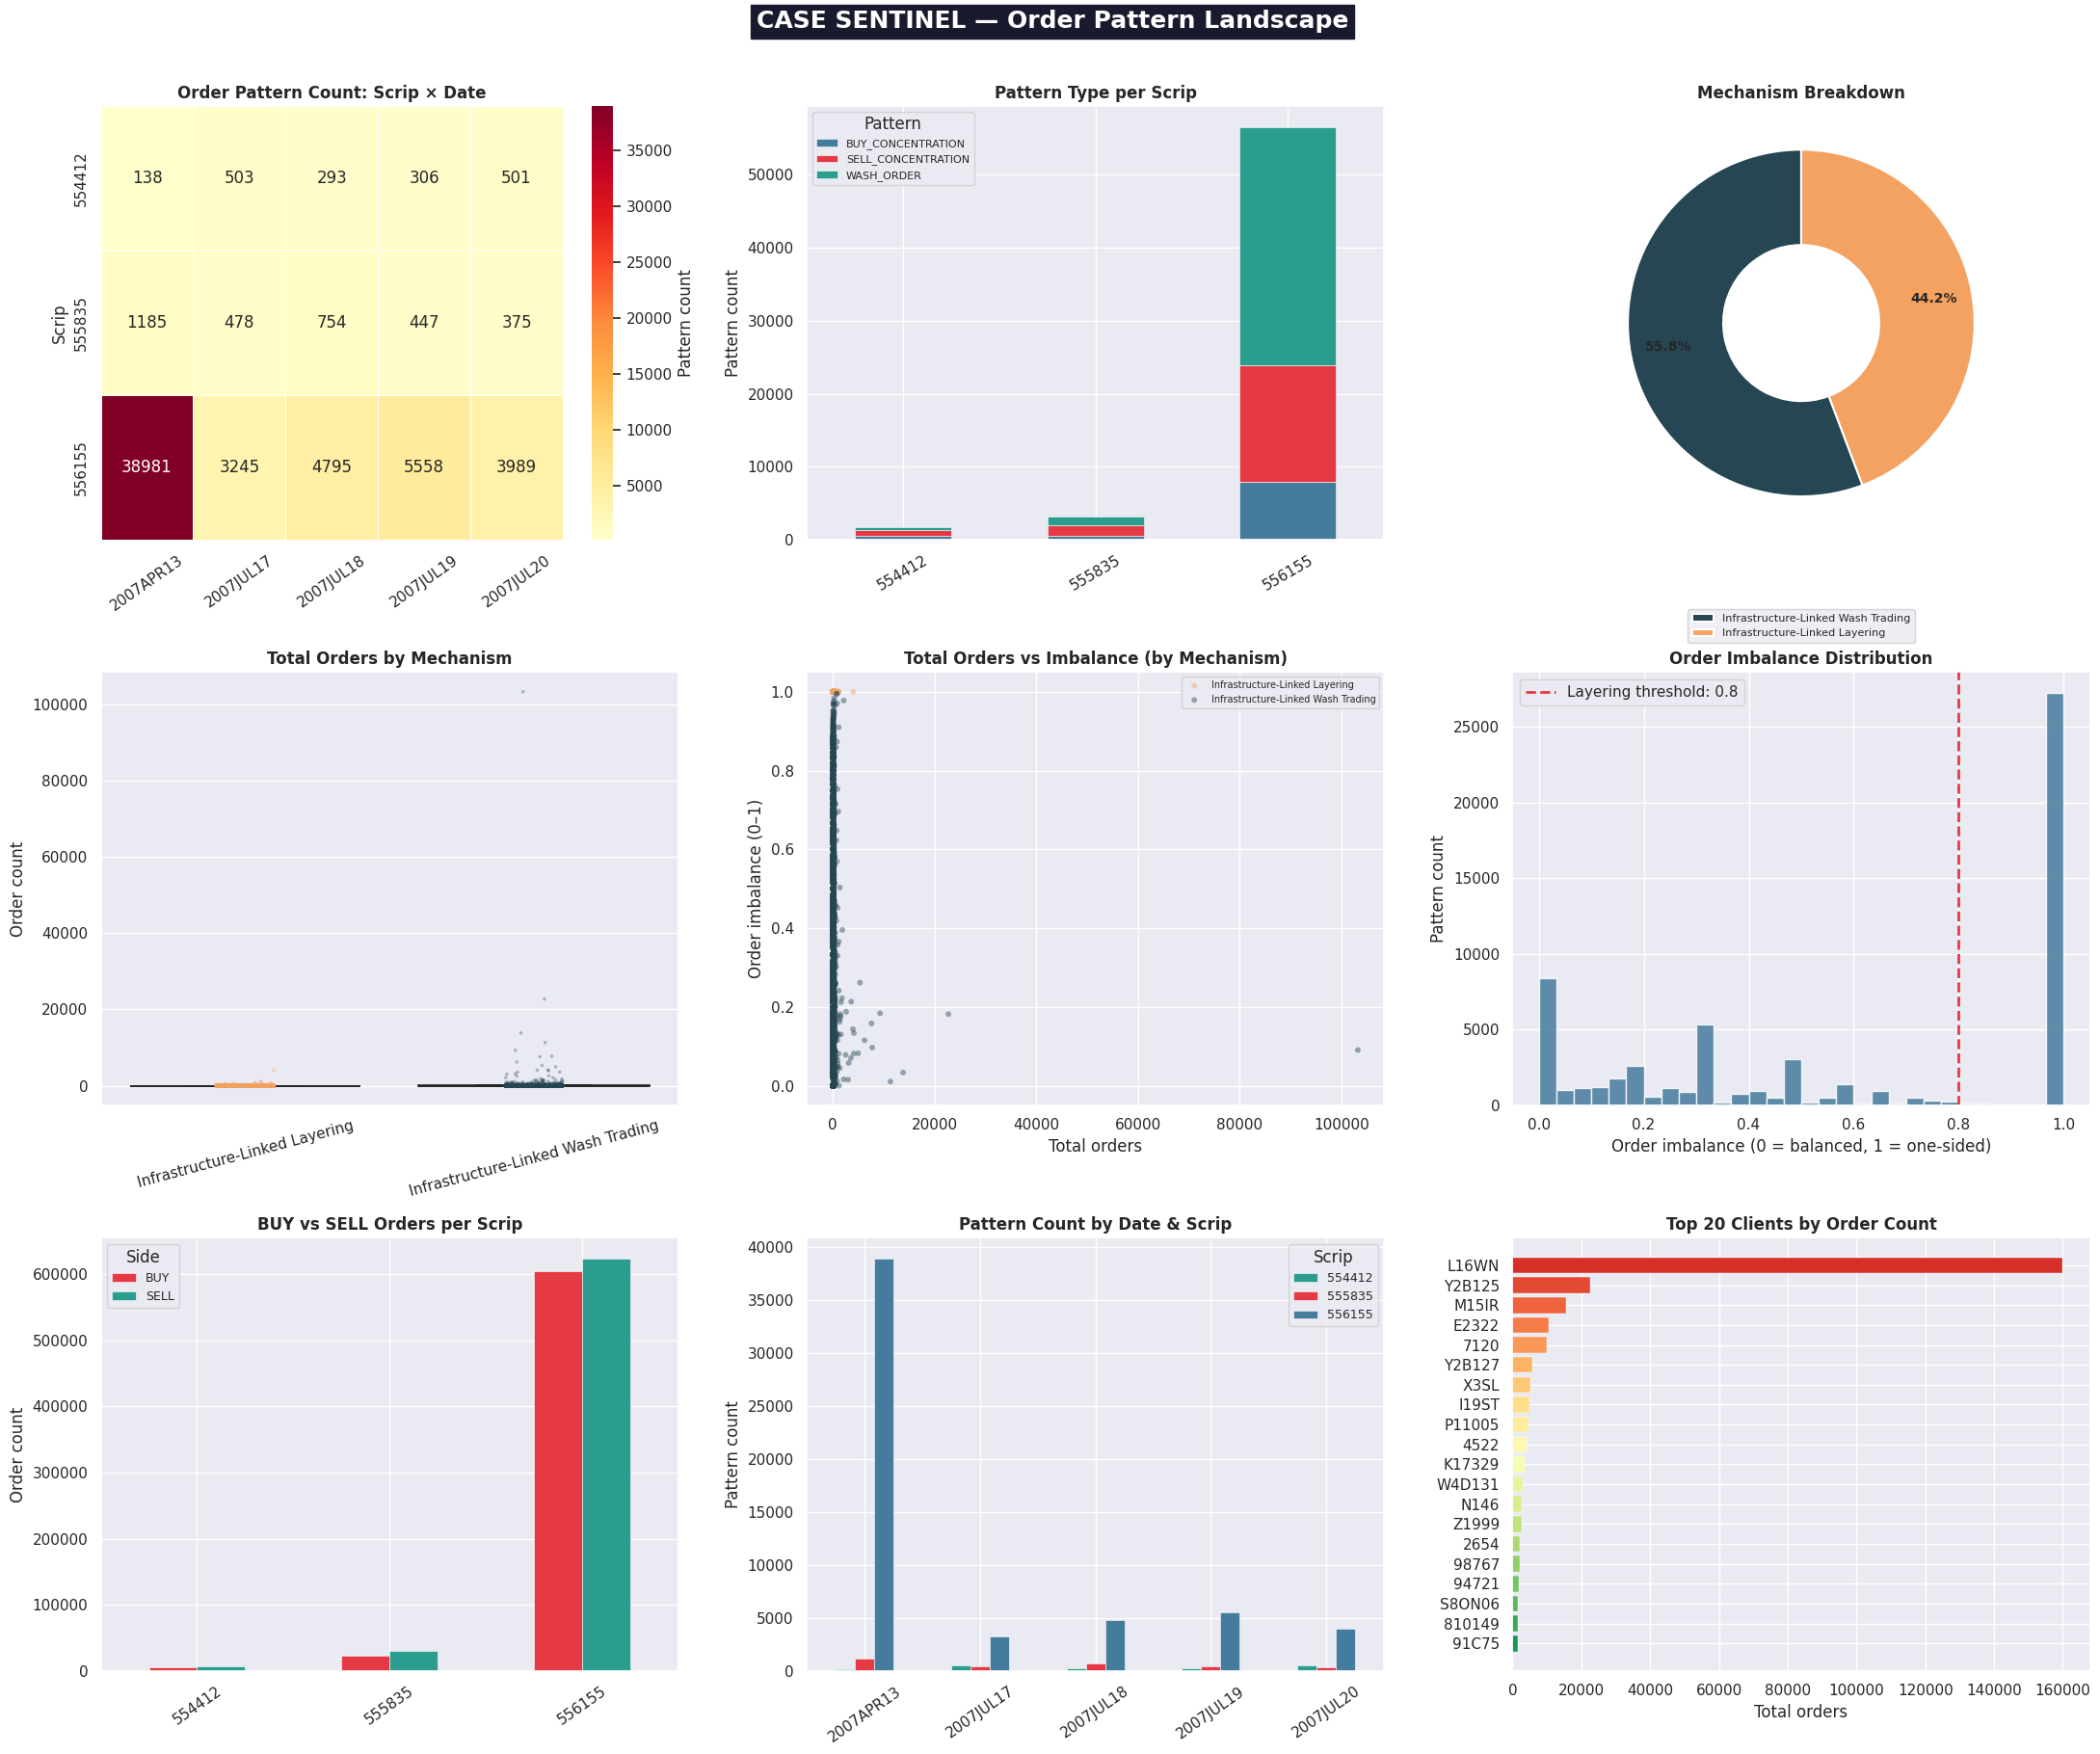

Figure 1 saved → sentinel_ord_fig1_patterns.png


In [11]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

# ── Global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', context='notebook', font='DejaVu Sans')
PALETTE   = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']
MECH_CLR  = {
    'Wash Trading'                      : '#E63946',
    'Layering'                          : '#457B9D',
    'Order Concentration'               : '#2A9D8F',
    'Infrastructure-Linked'             : '#E9C46A',
    'Infrastructure-Linked Layering'    : '#F4A261',
    'Infrastructure-Linked Wash Trading': '#264653',
}
TIER_CLR  = {'LOW': '#2A9D8F', 'MEDIUM': '#E9C46A', 'HIGH': '#F4A261', 'CRITICAL': '#E63946'}


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Order Pattern Landscape   (3 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(3, 3, figsize=(22, 18))
fig1.suptitle('CASE SENTINEL — Order Pattern Landscape',
              fontsize=18, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# 1a. HEATMAP  Patterns per Scrip × Date
ax = axes[0, 0]
heat = (order_patterns_df.groupby(['SCRIP_CODE', 'TRADE_DATE'])
        .size().reset_index(name='count')
        .pivot(index='SCRIP_CODE', columns='TRADE_DATE', values='count').fillna(0))
if not heat.empty:
    sns.heatmap(heat, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
                linewidths=.5, cbar_kws={'label': 'Pattern count'})
ax.set_title('Order Pattern Count: Scrip × Date', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Scrip')
ax.tick_params(axis='x', rotation=35)

# 1b. STACKED BAR  Pattern type per Scrip
ax = axes[0, 1]
grp = (order_patterns_df.groupby(['SCRIP_CODE', 'concentration_pattern'])
       .size().reset_index(name='n'))
if not grp.empty:
    pivot = grp.pivot_table(index='SCRIP_CODE', columns='concentration_pattern', values='n', fill_value=0)
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=['#457B9D','#E63946','#2A9D8F','#E9C46A'][:len(pivot.columns)],
               edgecolor='white', linewidth=0.4)
ax.set_title('Pattern Type per Scrip', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Pattern count'); ax.legend(title='Pattern', fontsize=8)

# 1c. DONUT  Mechanism breakdown
ax = axes[0, 2]
mech_s = patterns_full['mechanism'].value_counts()
wedge_colors = [MECH_CLR.get(m, '#888') for m in mech_s.index]
if not mech_s.empty:
    wedges, texts, autotexts = ax.pie(
        mech_s.values, labels=None, colors=wedge_colors,
        autopct='%1.1f%%', startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
    for at in autotexts:
        at.set_fontsize(10); at.set_fontweight('bold')
    ax.legend(mech_s.index, loc='lower center', fontsize=8, ncol=1,
              bbox_to_anchor=(0.5, -0.25))
ax.set_title('Mechanism Breakdown', fontweight='bold')

# 1d. BOX PLOT  Total orders by mechanism
ax = axes[1, 0]
if not patterns_full.empty:
    order_mechs = patterns_full['mechanism'].unique().tolist()
    sns.boxplot(data=patterns_full, x='mechanism', y='total_orders',
                palette={m: MECH_CLR.get(m,'#888') for m in order_mechs},
                ax=ax, showfliers=False, linewidth=1.2)
    sns.stripplot(data=patterns_full, x='mechanism', y='total_orders',
                  palette={m: MECH_CLR.get(m,'#888') for m in order_mechs},
                  ax=ax, size=2.5, alpha=0.35, jitter=True)
ax.set_title('Total Orders by Mechanism', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Order count')
ax.tick_params(axis='x', rotation=15)

# 1e. SCATTER  Order imbalance vs total orders  (color = mechanism)
ax = axes[1, 1]
for mech, grp_df in patterns_full.groupby('mechanism'):
    ax.scatter(grp_df['total_orders'], grp_df['order_imbalance'],
               label=mech, color=MECH_CLR.get(mech, '#888'),
               alpha=0.45, s=18, edgecolors='none')
ax.set_title('Total Orders vs Imbalance (by Mechanism)', fontweight='bold')
ax.set_xlabel('Total orders'); ax.set_ylabel('Order imbalance (0–1)')
ax.legend(fontsize=7)

# 1f. HISTOGRAM  Order imbalance distribution
ax = axes[1, 2]
imb_data = patterns_full['order_imbalance'].dropna()
ax.hist(imb_data, bins=30, color='#457B9D', edgecolor='white', alpha=0.85)
ax.axvline(LAYERING_THRESHOLD, color='#E63946', linewidth=2,
           linestyle='--', label=f'Layering threshold: {LAYERING_THRESHOLD}')
ax.set_title('Order Imbalance Distribution', fontweight='bold')
ax.set_xlabel('Order imbalance (0 = balanced, 1 = one-sided)')
ax.set_ylabel('Pattern count'); ax.legend()

# 1g. BAR  BUY vs SELL orders per scrip
ax = axes[2, 0]
side_scrip = (df.groupby(['SCRIP_CODE','order_side']).size().reset_index(name='n'))
if not side_scrip.empty:
    pivot_side = side_scrip.pivot(index='SCRIP_CODE', columns='order_side', values='n').fillna(0)
    pivot_side.plot(kind='bar', ax=ax,
                    color=['#E63946','#2A9D8F'][:len(pivot_side.columns)],
                    edgecolor='white', linewidth=0.4)
ax.set_title('BUY vs SELL Orders per Scrip', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Order count'); ax.legend(title='Side', fontsize=9)

# 1h. GROUPED BAR  Patterns per Date, coloured by Scrip
ax = axes[2, 1]
date_scrip = (order_patterns_df.groupby(['TRADE_DATE','SCRIP_CODE'])
              .size().reset_index(name='n'))
if not date_scrip.empty:
    pivot2 = date_scrip.pivot(index='TRADE_DATE', columns='SCRIP_CODE', values='n').fillna(0)
    pivot2.plot(kind='bar', ax=ax, color=['#2A9D8F','#E63946','#457B9D','#E9C46A'][:len(pivot2.columns)],
                edgecolor='white', linewidth=0.4)
ax.set_title('Pattern Count by Date & Scrip', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Pattern count'); ax.legend(title='Scrip', fontsize=9)

# 1i. BAR  Orders per client (top 20)
ax = axes[2, 2]
top20_clients = vol_per_client.sort_values('total_ord_count', ascending=False).head(20)
colors_ord = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top20_clients)))
ax.barh(top20_clients['client_id'][::-1].astype(str),
        top20_clients['total_ord_count'][::-1],
        color=colors_ord, edgecolor='white', linewidth=0.3)
ax.set_title('Top 20 Clients by Order Count', fontweight='bold')
ax.set_xlabel('Total orders')

plt.tight_layout()
plt.savefig(r'E:\Synapse-BI\sentinel_orders_charts\sentinel_ord_fig1_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved → sentinel_ord_fig1_patterns.png")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Suspect Validation & Risk Scoring   (3 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(3, 3, figsize=(22, 18))
fig2.suptitle('CASE SENTINEL — Suspect Validation & Risk Scoring (Orders)',
              fontsize=18, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# 2a. DONUT  Validation status
ax = axes2[0, 0]
vstatus = validation['validation_status'].value_counts()
vcolors = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A', 'INSUFFICIENT EVIDENCE': '#457B9D'}
wc = [vcolors.get(s, '#888') for s in vstatus.index]
if not vstatus.empty:
    _, _, autotexts = ax.pie(
        vstatus.values, colors=wc, autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
    for at in autotexts:
        at.set_fontsize(10); at.set_fontweight('bold')
    ax.legend(vstatus.index, loc='lower center', fontsize=9,
              bbox_to_anchor=(0.5, -0.22))
ax.set_title('Suspect Validation Status (Orders)', fontweight='bold')

# 2b. HORIZONTAL BAR  Top 20 confirmed clients
ax = axes2[0, 1]
top_confirmed = (validation[validation['validation_status'] == 'CONFIRMED']
                 .sort_values('pattern_count', ascending=False).head(20))
if not top_confirmed.empty:
    cmap_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_confirmed)))
    ax.barh(top_confirmed['client_id'][::-1].astype(str),
            top_confirmed['pattern_count'][::-1],
            color=cmap_bar, edgecolor='white', linewidth=0.3)
    ax.axvline(top_confirmed['pattern_count'].median(), color='#264653',
               linestyle='--', linewidth=1.5, label='Median')
    ax.legend(fontsize=9)
ax.set_title('Top 20 CONFIRMED — Pattern Count', fontweight='bold')
ax.set_xlabel('Pattern count')

# 2c. HISTOGRAM  Risk score distribution with tier shading
ax = axes2[0, 2]
scores = client_scores_final['Risk_Score'].dropna()
ax.hist(scores, bins=60, color='#457B9D', edgecolor='white', alpha=0.85)
tier_edges = [(-1, 25, '#2A9D8F', 'LOW'), (25, 50, '#E9C46A', 'MEDIUM'),
              (50, 75, '#F4A261', 'HIGH'), (75, 101, '#E63946', 'CRITICAL')]
for lo, hi, c, lbl in tier_edges:
    ax.axvspan(lo, hi, alpha=0.12, color=c, label=lbl)
ax.set_title('Client Risk Score Distribution (Orders)', fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Client count')
ax.legend(fontsize=8, ncol=2)

# 2d. HEATMAP  Signal matrix for top 25 clients
ax = axes2[1, 0]
top25 = client_scores_final.head(25).set_index('client_id')[['S1','S2','S3','S4','S5']]
if not top25.empty:
    sns.heatmap(top25.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.3, cbar_kws={'label': 'Signal strength (0–1)'},
                xticklabels=True, yticklabels=True)
ax.set_title('Signal Heatmap — Top 25 Clients\n(rows=signals, cols=clients)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# 2e. BAR  Evidence strength distribution
ax = axes2[1, 1]
es = client_scores_final['Evidence_Strength'].value_counts().sort_index()
bar_colors_es = ['#2A9D8F','#2A9D8F','#2A9D8F','#E9C46A','#F4A261','#E63946']
ax.bar(es.index, es.values,
       color=[bar_colors_es[min(int(i), 5)] for i in es.index],
       edgecolor='white', linewidth=0.5)
ax.set_title('Evidence Strength Distribution\n(# signals ≥ 0.5)', fontweight='bold')
ax.set_xlabel('Signals firing'); ax.set_ylabel('Client count')
for i_val, v in zip(es.index, es.values):
    ax.text(i_val, v + 0.5, str(v), ha='center', fontsize=9)

# 2f. SCATTER  Reciprocity ratio vs Pattern count
ax = axes2[1, 2]
cmap_val = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A', 'INSUFFICIENT EVIDENCE': '#457B9D'}
for status, grp_v in validation[validation['pattern_count'] > 0].groupby('validation_status'):
    ax.scatter(grp_v['pattern_count'], grp_v['reciprocity_ratio'],
               label=status, color=cmap_val.get(status, '#888'),
               alpha=0.5, s=20, edgecolors='none')
ax.set_title('Reciprocity Ratio vs Pattern Count\n(suspects with ≥1 pattern)',
             fontweight='bold')
ax.set_xlabel('Pattern count'); ax.set_ylabel('Reciprocity ratio (BUY/SELL balance)')
ax.axhline(0.5, color='#264653', linestyle='--', linewidth=1.2, label='Threshold 0.5')
ax.legend(fontsize=8)

# 2g. BAR  Client Risk Tier breakdown
ax = axes2[2, 0]
tier_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
tier_counts = client_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, tier_counts.values,
       color=[TIER_CLR[t] for t in tier_order], edgecolor='white', linewidth=0.5)
ax.set_title('Client Risk Tier Distribution (Orders)', fontweight='bold')
ax.set_ylabel('Client count')
for i_t, (t, v) in enumerate(zip(tier_order, tier_counts)):
    ax.text(i_t, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

# 2h. BAR  Average signal values across Risk Tiers
ax = axes2[2, 1]
signal_means = (client_scores_final
                .groupby('Risk_Tier')[['S1','S2','S3','S4','S5']].mean()
                .reindex(['LOW','MEDIUM','HIGH','CRITICAL']))
signal_means.T.plot(kind='bar', ax=ax,
                    color=[TIER_CLR[t] for t in ['LOW','MEDIUM','HIGH','CRITICAL']],
                    edgecolor='white', linewidth=0.4)
ax.set_title('Mean Signal Values per Risk Tier (Orders)', fontweight='bold')
ax.set_xlabel('Signal'); ax.set_ylabel('Mean signal value')
ax.set_ylim(0, 1.05); ax.legend(title='Risk Tier', fontsize=8)
ax.tick_params(axis='x', rotation=0)

# 2i. SCATTER  Total orders vs reciprocity (bubble = pattern count)
ax = axes2[2, 2]
plot_df = validation[validation['pattern_count'] > 0].copy()
plot_df['sz'] = np.sqrt(plot_df['pattern_count']) * 8
for status, grp_v in plot_df.groupby('validation_status'):
    ax.scatter(grp_v['total_orders'], grp_v['reciprocity_ratio'],
               s=grp_v['sz'], alpha=0.5,
               color=cmap_val.get(status, '#888'),
               edgecolors='none', label=status)
ax.set_title('Total Orders vs Reciprocity\n(bubble = pattern count)',
             fontweight='bold')
ax.set_xlabel('Total orders'); ax.set_ylabel('Reciprocity ratio')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'E:\Synapse-BI\sentinel_orders_charts\sentinel_ord_fig2_suspects.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved → sentinel_ord_fig2_suspects.png")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Network, Members & New Entities   (3 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(3, 3, figsize=(22, 18))
fig3.suptitle('CASE SENTINEL — Network, Members & New-Entity Detection (Orders)',
              fontsize=18, fontweight='bold',
              color='#FFFFFF', backgroundcolor='#1A1A2E', y=1.01)

# 3a. HORIZONTAL BAR  Top 15 members by client count
ax = axes3[0, 0]
top_mb = member_stats.head(15)
bar_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_mb)))
ax.barh(top_mb['member_code'].astype(str)[::-1],
        top_mb['client_count'][::-1],
        color=bar_c, edgecolor='white', linewidth=0.3)
ax.set_title('Top 15 Members by Client Count (Orders)', fontweight='bold')
ax.set_xlabel('Unique clients served')

# 3b. SCATTER  Member risk M1 vs M2 (bubble = M3)
ax = axes3[0, 1]
ms = member_scores_final.copy()
tier_c = [TIER_CLR.get(str(t), '#888') for t in ms['Risk_Tier']]
ax.scatter(ms['M1'], ms['M2'],
           s=(ms['M3'] * 300 + 10).clip(10, 300),
           c=tier_c, alpha=0.6, edgecolors='none')
ax.set_title('Member Signal Space  M1 vs M2\n(bubble = order volume M3)', fontweight='bold')
ax.set_xlabel('M1 — Pattern-client involvement')
ax.set_ylabel('M2 — Client breadth')
for t, c in TIER_CLR.items():
    ax.scatter([], [], c=c, s=60, label=t)
ax.legend(title='Risk Tier', fontsize=8)

# 3c. MEMBER RISK TIER bar
ax = axes3[0, 2]
m_tier_counts = member_scores_final['Risk_Tier'].value_counts().reindex(
    ['LOW','MEDIUM','HIGH','CRITICAL'], fill_value=0)
ax.bar(['LOW','MEDIUM','HIGH','CRITICAL'], m_tier_counts.values,
       color=[TIER_CLR[t] for t in ['LOW','MEDIUM','HIGH','CRITICAL']],
       edgecolor='white', linewidth=0.5)
ax.set_title('Member Risk Tier Distribution (Orders)', fontweight='bold')
ax.set_ylabel('Member count')
for i_t, (t, v) in enumerate(zip(['LOW','MEDIUM','HIGH','CRITICAL'], m_tier_counts)):
    ax.text(i_t, v + 0.2, str(v), ha='center', fontsize=10, fontweight='bold')

# 3d. NETWORKX  Subgraph: top 40 order clients
ax = axes3[1, 0]
ax.set_facecolor('#0D1117')
top_nodes_ord = (pat_stats.sort_values('pattern_count', ascending=False)
                 .head(40)['client_id'].astype(str).tolist())
top_set_ord = set(top_nodes_ord)

# Build client-client co-occurrence graph (clients sharing same scrip/date session)
co_edges = []
session_grp = df.groupby(['SCRIP_CODE','TRADE_DATE'])['client_id'].apply(list)
for clients_in_session in session_grp:
    unq = [str(c) for c in set(clients_in_session) if str(c) in top_set_ord]
    for i_c in range(len(unq)):
        for j_c in range(i_c+1, len(unq)):
            co_edges.append((unq[i_c], unq[j_c]))

H = nx.Graph()
H.add_nodes_from(top_nodes_ord)
H.add_edges_from(co_edges)

pat_count_map = pat_stats.set_index('client_id')['pattern_count'].to_dict()
vstatus_map_ord = validation.set_index('client_id')['validation_status'].to_dict()
node_sizes  = [max(pat_count_map.get(n,1) * 15, 50) for n in H.nodes()]
node_colors = [{'CONFIRMED':'#E63946','PARTIAL':'#E9C46A'}.get(
                vstatus_map_ord.get(n,''), '#457B9D') for n in H.nodes()]

pos = nx.spring_layout(H, k=1.2, seed=42)
nx.draw_networkx(H, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                 edge_color='#3A3A5A', with_labels=True, font_size=5,
                 font_color='white', width=0.5, alpha=0.9)
ax.set_title('Client Order Network — Top 40 Pattern Participants\n'
             '(red=CONFIRMED, yellow=PARTIAL, blue=other)',
             fontweight='bold', color='white')
ax.set_axis_off()

# 3e. BAR  New entity detection method breakdown
ax = axes3[1, 1]
method_counts_ord = {
    'Pattern\nParticipation'  : len(new_from_patterns),
    'Rapid\nFire'             : len(rapid_new),
    'Order\nVolume'           : len(high_ord),
    'Pattern+Rapid\n(both)'   : len(new_from_patterns & rapid_new),
    'Pattern+OrdVol\n(both)'  : len(new_from_patterns & high_ord),
    'All three'               : len(new_from_patterns & rapid_new & high_ord),
}
colors_m = ['#457B9D','#2A9D8F','#E9C46A','#F4A261','#E63946','#264653']
ax.bar(method_counts_ord.keys(), method_counts_ord.values(),
       color=colors_m, edgecolor='white', linewidth=0.5)
ax.set_title('New Entity Detection Method Breakdown (Orders)', fontweight='bold')
ax.set_ylabel('Entity count')
for i_m, (k, v) in enumerate(method_counts_ord.items()):
    ax.text(i_m, v + 0.3, str(v), ha='center', fontsize=9)
ax.tick_params(axis='x', labelsize=8)

# 3f. HISTOGRAM  New entity risk scores
ax = axes3[1, 2]
new_scores = new_entities_final['Risk_Score'].dropna()
ax.hist(new_scores, bins=50, color='#2A9D8F', edgecolor='white', alpha=0.85)
for lo, hi, c, lbl in tier_edges:
    ax.axvspan(lo, hi, alpha=0.1, color=c, label=lbl)
ax.set_title('New (Unlisted) Entity Risk Score Distribution (Orders)',
             fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Entity count')
ax.legend(fontsize=8, ncol=2)

# 3g. SCATTER  Buy orders vs Sell orders (balance cloud)
ax = axes3[2, 0]
rd_ord = side_df[['n_buy_total','n_sell_total']].copy()
rd_ord = rd_ord[(rd_ord['n_buy_total'] > 0) | (rd_ord['n_sell_total'] > 0)]
ax.scatter(rd_ord['n_buy_total'], rd_ord['n_sell_total'],
           alpha=0.3, s=8, color='#457B9D', edgecolors='none')
lim_max = max(rd_ord['n_buy_total'].quantile(0.99),
              rd_ord['n_sell_total'].quantile(0.99)) + 1
ax.plot([0, lim_max], [0, lim_max], color='#E63946', linewidth=1.5,
        linestyle='--', label='Perfect balance')
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_title('BUY Orders vs SELL Orders\n(on-diagonal = perfectly balanced)',
             fontweight='bold')
ax.set_xlabel('BUY order count'); ax.set_ylabel('SELL order count')
ax.legend(fontsize=9)

# 3h. RANKED DOT PLOT  Top 25 client risk ranking
ax = axes3[2, 1]
top25_risk = client_scores_final.head(25).reset_index(drop=True)
dot_c = [TIER_CLR.get(str(t), '#888') for t in top25_risk['Risk_Tier']]
ax.scatter(top25_risk['Risk_Score'],
           range(len(top25_risk))[::-1],
           c=dot_c, s=80, zorder=3)
for i_r, row in top25_risk.iterrows():
    ax.plot([0, row['Risk_Score']], [len(top25_risk)-1-i_r]*2,
            color='#3A3A5A', linewidth=1.2, zorder=2)
ax.set_yticks(range(len(top25_risk)))
ax.set_yticklabels(top25_risk['client_id'].astype(str)[::-1], fontsize=8)
ax.set_xlabel('Risk Score')
ax.set_title('Top 25 Client Risk Ranking — Orders\n(coloured by tier)', fontweight='bold')
ax.axvline(75, color='#E63946', linestyle='--', linewidth=1, label='CRITICAL threshold')
ax.legend(fontsize=8)

# 3i. BAR  Order side distribution per member (top 10)
ax = axes3[2, 2]
top10_mb = member_stats.head(10)['member_code'].astype(str).tolist()
mb_side = (df[df['member_code'].astype(str).isin(top10_mb)]
           .groupby(['member_code','order_side']).size().reset_index(name='n'))
if not mb_side.empty:
    pivot_mb = mb_side.pivot(index='member_code', columns='order_side', values='n').fillna(0)
    pivot_mb.plot(kind='bar', ax=ax,
                  color=['#E63946','#2A9D8F'][:len(pivot_mb.columns)],
                  edgecolor='white', linewidth=0.4)
ax.set_title('BUY vs SELL Orders — Top 10 Members', fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Order count'); ax.legend(title='Side', fontsize=9)

plt.tight_layout()
plt.savefig(r'E:\Synapse-BI\sentinel_orders_charts\sentinel_ord_fig3_network.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved → sentinel_ord_fig3_network.png")

In [ ]:
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# ── Output directory ──────────────────────────────────────────────────────────
OUT_DIR = r'E:\Synapse-BI\sentinel_orders_charts'
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style='darkgrid', context='notebook', font='DejaVu Sans')
PALETTE  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']
MECH_CLR = {
    'Wash Trading'                      : '#E63946',
    'Layering'                          : '#457B9D',
    'Order Concentration'               : '#2A9D8F',
    'Infrastructure-Linked'             : '#E9C46A',
    'Infrastructure-Linked Layering'    : '#F4A261',
    'Infrastructure-Linked Wash Trading': '#264653',
}
TIER_CLR = {'LOW': '#2A9D8F', 'MEDIUM': '#E9C46A', 'HIGH': '#F4A261', 'CRITICAL': '#E63946'}
saved = []

def save(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    saved.append(name)

tier_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']

# ══════════════════════════════════════════════════════════════════════════════
# 01 — Heatmap: Pattern Count per Scrip × Date
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
heat = (order_patterns_df.groupby(['SCRIP_CODE', 'TRADE_DATE'])
        .size().reset_index(name='count')
        .pivot(index='SCRIP_CODE', columns='TRADE_DATE', values='count').fillna(0))
if not heat.empty:
    sns.heatmap(heat, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
                linewidths=.5, cbar_kws={'label': 'Pattern count'})
ax.set_title('Order Pattern Count: Scrip × Date', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Scrip'); ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); save('01_ord_heatmap_patterns_scrip_date.png')

# ══════════════════════════════════════════════════════════════════════════════
# 02 — Stacked Bar: Pattern Type per Scrip-Date
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
grp = (order_patterns_df.groupby(['SCRIP_CODE', 'TRADE_DATE', 'concentration_pattern'])
       .size().reset_index(name='n'))
grp['label'] = grp['SCRIP_CODE'] + '\n' + grp['TRADE_DATE']
if not grp.empty:
    pivot = grp.pivot_table(index='label', columns='concentration_pattern', values='n', fill_value=0)
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=['#457B9D','#E63946','#2A9D8F','#E9C46A'][:len(pivot.columns)],
               edgecolor='white', linewidth=0.4)
ax.set_title('Pattern Type per Scrip-Date', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Pattern count'); ax.legend(title='Pattern', fontsize=9)
plt.tight_layout(); save('02_ord_bar_pattern_type.png')

# ══════════════════════════════════════════════════════════════════════════════
# 03 — Donut: Mechanism Breakdown
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 7))
mech_s = patterns_full['mechanism'].value_counts()
wc2 = [MECH_CLR.get(m, '#888') for m in mech_s.index]
if not mech_s.empty:
    _, _, autotexts = ax.pie(
        mech_s.values, labels=None, colors=wc2, autopct='%1.1f%%', startangle=90,
        pctdistance=0.78, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
    for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
    ax.legend(mech_s.index, loc='lower center', fontsize=10, ncol=1,
              bbox_to_anchor=(0.5, -0.20))
ax.set_title('Mechanism Breakdown (Orders)', fontsize=14, fontweight='bold')
plt.tight_layout(); save('03_ord_donut_mechanism.png')

# ══════════════════════════════════════════════════════════════════════════════
# 04 — Box+Strip: Total Orders by Mechanism
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
if not patterns_full.empty:
    ex_mechs = patterns_full['mechanism'].unique().tolist()
    sns.boxplot(data=patterns_full, x='mechanism', y='total_orders',
                palette={m: MECH_CLR.get(m,'#888') for m in ex_mechs},
                ax=ax, showfliers=False, linewidth=1.2)
    sns.stripplot(data=patterns_full, x='mechanism', y='total_orders',
                  palette={m: MECH_CLR.get(m,'#888') for m in ex_mechs},
                  ax=ax, size=2.5, alpha=0.35, jitter=True)
ax.set_title('Total Orders per Pattern by Mechanism', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Order count')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout(); save('04_ord_box_orders_by_mechanism.png')

# ══════════════════════════════════════════════════════════════════════════════
# 05 — Scatter: Total Orders vs Imbalance (log × linear)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
for mech, gdf in patterns_full.groupby('mechanism'):
    ax.scatter(gdf['total_orders'], gdf['order_imbalance'],
               label=mech, color=MECH_CLR.get(mech, '#888'),
               alpha=0.45, s=18, edgecolors='none')
ax.set_title('Total Orders vs Imbalance (by Mechanism)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total orders'); ax.set_ylabel('Order imbalance (0–1)')
ax.legend(fontsize=8)
plt.tight_layout(); save('05_ord_scatter_orders_vs_imbalance.png')

# ══════════════════════════════════════════════════════════════════════════════
# 06 — Histogram: Order Imbalance Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
imb_data = patterns_full['order_imbalance'].dropna()
ax.hist(imb_data, bins=30, color='#457B9D', edgecolor='white', alpha=0.85)
ax.axvline(LAYERING_THRESHOLD, color='#E63946', linewidth=2,
           linestyle='--', label=f'Layering threshold: {LAYERING_THRESHOLD}')
ax.set_title('Order Imbalance Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Imbalance (0 = balanced, 1 = one-sided)'); ax.set_ylabel('Pattern count')
ax.legend()
plt.tight_layout(); save('06_ord_hist_imbalance.png')

# ══════════════════════════════════════════════════════════════════════════════
# 07 — Bar: BUY vs SELL Orders per Scrip
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
side_scrip = df.groupby(['SCRIP_CODE','order_side']).size().reset_index(name='n')
if not side_scrip.empty:
    piv_ss = side_scrip.pivot(index='SCRIP_CODE', columns='order_side', values='n').fillna(0)
    piv_ss.plot(kind='bar', ax=ax, color=['#E63946','#2A9D8F'][:len(piv_ss.columns)],
                edgecolor='white', linewidth=0.4)
ax.set_title('BUY vs SELL Orders per Scrip', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Order count'); ax.legend(title='Side', fontsize=9)
plt.tight_layout(); save('07_ord_bar_buy_vs_sell_per_scrip.png')

# ══════════════════════════════════════════════════════════════════════════════
# 08 — Grouped Bar: Pattern Count by Date & Scrip
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
date_scrip = (order_patterns_df.groupby(['TRADE_DATE','SCRIP_CODE'])
              .size().reset_index(name='n'))
if not date_scrip.empty:
    piv_ds = date_scrip.pivot(index='TRADE_DATE', columns='SCRIP_CODE', values='n').fillna(0)
    piv_ds.plot(kind='bar', ax=ax, color=['#2A9D8F','#E63946','#457B9D','#E9C46A'][:len(piv_ds.columns)],
                edgecolor='white', linewidth=0.4)
ax.set_title('Order Pattern Count by Date & Scrip', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('Pattern count'); ax.legend(title='Scrip', fontsize=9)
plt.tight_layout(); save('08_ord_bar_patterns_by_date_scrip.png')

# ══════════════════════════════════════════════════════════════════════════════
# 09 — Horizontal Bar: Top 20 Clients by Order Count
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 8))
top20_c = vol_per_client.sort_values('total_ord_count', ascending=False).head(20)
colors_top20 = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top20_c)))
ax.barh(top20_c['client_id'][::-1].astype(str), top20_c['total_ord_count'][::-1],
        color=colors_top20, edgecolor='white', linewidth=0.3)
ax.set_title('Top 20 Clients by Order Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Total orders')
plt.tight_layout(); save('09_ord_hbar_top20_clients.png')

# ══════════════════════════════════════════════════════════════════════════════
# 10 — Donut: Suspect Validation Status
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 7))
vstatus = validation['validation_status'].value_counts()
vcolors = {'CONFIRMED': '#E63946', 'PARTIAL': '#E9C46A', 'INSUFFICIENT EVIDENCE': '#457B9D'}
wc3 = [vcolors.get(s, '#888') for s in vstatus.index]
if not vstatus.empty:
    _, _, autotexts2 = ax.pie(
        vstatus.values, colors=wc3, autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
    for at in autotexts2: at.set_fontsize(12); at.set_fontweight('bold')
    ax.legend(vstatus.index, loc='lower center', fontsize=10, bbox_to_anchor=(0.5, -0.15))
ax.set_title('Suspect Validation Status (Orders)', fontsize=14, fontweight='bold')
plt.tight_layout(); save('10_ord_donut_validation_status.png')

# ══════════════════════════════════════════════════════════════════════════════
# 11 — Horizontal Bar: Top 20 CONFIRMED Clients
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7))
top_conf = (validation[validation['validation_status'] == 'CONFIRMED']
            .sort_values('pattern_count', ascending=False).head(20))
if not top_conf.empty:
    cmap_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_conf)))
    ax.barh(top_conf['client_id'][::-1].astype(str), top_conf['pattern_count'][::-1],
            color=cmap_bar, edgecolor='white', linewidth=0.3)
    ax.axvline(top_conf['pattern_count'].median(), color='#264653',
               linestyle='--', linewidth=1.5, label='Median')
    ax.legend(fontsize=9)
ax.set_title('Top 20 CONFIRMED Clients — Pattern Count (Orders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pattern count')
plt.tight_layout(); save('11_ord_hbar_confirmed_clients.png')

# ══════════════════════════════════════════════════════════════════════════════
# 12 — Histogram: Client Risk Score Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
scores = client_scores_final['Risk_Score'].dropna()
ax.hist(scores, bins=60, color='#457B9D', edgecolor='white', alpha=0.85)
for lo, hi, c, lbl in [(-1,25,'#2A9D8F','LOW'),(25,50,'#E9C46A','MEDIUM'),
                        (50,75,'#F4A261','HIGH'),(75,101,'#E63946','CRITICAL')]:
    ax.axvspan(lo, hi, alpha=0.12, color=c, label=lbl)
ax.set_title('Client Risk Score Distribution (Orders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Client count')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); save('12_ord_hist_client_risk_scores.png')

# ══════════════════════════════════════════════════════════════════════════════
# 13 — Heatmap: Signal Matrix for Top 25 Clients
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
top25 = client_scores_final.head(25).set_index('client_id')[['S1','S2','S3','S4','S5']]
if not top25.empty:
    sns.heatmap(top25.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.3, cbar_kws={'label': 'Signal strength (0–1)'})
ax.set_title('Signal Heatmap — Top 25 Order Clients', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); save('13_ord_heatmap_signals_top25.png')

# ══════════════════════════════════════════════════════════════════════════════
# 14 — Bar: Evidence Strength Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
es = client_scores_final['Evidence_Strength'].value_counts().sort_index()
bar_es_c = ['#2A9D8F','#2A9D8F','#2A9D8F','#E9C46A','#F4A261','#E63946']
ax.bar(es.index, es.values,
       color=[bar_es_c[min(int(i),5)] for i in es.index],
       edgecolor='white', linewidth=0.5)
ax.set_title('Evidence Strength Distribution\n(# signals ≥ 0.5, Orders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Signals firing'); ax.set_ylabel('Client count')
for i_v, v in zip(es.index, es.values):
    ax.text(i_v, v + 0.3, str(v), ha='center', fontsize=10)
plt.tight_layout(); save('14_ord_bar_evidence_strength.png')

# ══════════════════════════════════════════════════════════════════════════════
# 15 — Scatter: Reciprocity Ratio vs Pattern Count
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
cmap_val = {'CONFIRMED':'#E63946','PARTIAL':'#E9C46A','INSUFFICIENT EVIDENCE':'#457B9D'}
for status, gv in validation[validation['pattern_count'] > 0].groupby('validation_status'):
    ax.scatter(gv['pattern_count'], gv['reciprocity_ratio'],
               label=status, color=cmap_val.get(status,'#888'),
               alpha=0.5, s=20, edgecolors='none')
ax.axhline(0.5, color='#264653', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_title('Reciprocity Ratio vs Pattern Count (Orders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pattern count'); ax.set_ylabel('Reciprocity ratio')
ax.legend(fontsize=9)
plt.tight_layout(); save('15_ord_scatter_reciprocity_vs_patterns.png')

# ══════════════════════════════════════════════════════════════════════════════
# 16 — Bar: Client Risk Tier Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
tier_counts = client_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, tier_counts.values,
       color=[TIER_CLR[t] for t in tier_order], edgecolor='white', linewidth=0.5)
ax.set_title('Client Risk Tier Distribution (Orders)', fontsize=14, fontweight='bold')
ax.set_ylabel('Client count')
for i_t, (t, v) in enumerate(zip(tier_order, tier_counts)):
    ax.text(i_t, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); save('16_ord_bar_client_risk_tiers.png')

# ══════════════════════════════════════════════════════════════════════════════
# 17 — Grouped Bar: Mean Signal Values per Risk Tier
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
signal_means = (client_scores_final
                .groupby('Risk_Tier')[['S1','S2','S3','S4','S5']].mean()
                .reindex(['LOW','MEDIUM','HIGH','CRITICAL']))
signal_means.T.plot(kind='bar', ax=ax,
                    color=[TIER_CLR[t] for t in ['LOW','MEDIUM','HIGH','CRITICAL']],
                    edgecolor='white', linewidth=0.4)
ax.set_title('Mean Signal Values per Risk Tier (Orders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Signal'); ax.set_ylabel('Mean signal value')
ax.set_ylim(0, 1.05); ax.legend(title='Risk Tier', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); save('17_ord_bar_mean_signals_per_tier.png')

# ══════════════════════════════════════════════════════════════════════════════
# 18 — Bubble Scatter: Total Orders vs Reciprocity (bubble = pattern count)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = validation[validation['pattern_count'] > 0].copy()
plot_df['sz'] = np.sqrt(plot_df['pattern_count']) * 8
for status, gv in plot_df.groupby('validation_status'):
    ax.scatter(gv['total_orders'], gv['reciprocity_ratio'],
               s=gv['sz'], alpha=0.5,
               color=cmap_val.get(status,'#888'), edgecolors='none', label=status)
ax.set_title('Total Orders vs Reciprocity\n(bubble size = pattern count)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total orders'); ax.set_ylabel('Reciprocity ratio')
ax.legend(fontsize=9)
plt.tight_layout(); save('18_ord_bubble_orders_vs_reciprocity.png')

# ══════════════════════════════════════════════════════════════════════════════
# 19 — Horizontal Bar: Top 15 Members by Client Count
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))
top_mb = member_stats.head(15)
bar_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_mb)))
ax.barh(top_mb['member_code'].astype(str)[::-1], top_mb['client_count'][::-1],
        color=bar_c, edgecolor='white', linewidth=0.3)
ax.set_title('Top 15 Members by Client Count (Orders)', fontsize=14, fontweight='bold')
ax.set_xlabel('Unique clients served')
plt.tight_layout(); save('19_ord_hbar_members_by_clients.png')

# ══════════════════════════════════════════════════════════════════════════════
# 20 — Bubble Scatter: Member Signal Space M1 vs M2
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))
ms2 = member_scores_final.copy()
tier_c2 = [TIER_CLR.get(str(t), '#888') for t in ms2['Risk_Tier']]
ax.scatter(ms2['M1'], ms2['M2'],
           s=(ms2['M3'] * 300 + 10).clip(10, 300), c=tier_c2, alpha=0.6, edgecolors='none')
for t, c in TIER_CLR.items():
    ax.scatter([], [], c=c, s=60, label=t)
ax.set_title('Member Signal Space  M1 vs M2\n(bubble = order volume M3)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('M1 — Pattern-client involvement'); ax.set_ylabel('M2 — Client breadth')
ax.legend(title='Risk Tier', fontsize=9)
plt.tight_layout(); save('20_ord_bubble_member_signals.png')

# ══════════════════════════════════════════════════════════════════════════════
# 21 — Bar: Member Risk Tier Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
m_tc = member_scores_final['Risk_Tier'].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_order, m_tc.values,
       color=[TIER_CLR[t] for t in tier_order], edgecolor='white', linewidth=0.5)
ax.set_title('Member Risk Tier Distribution (Orders)', fontsize=14, fontweight='bold')
ax.set_ylabel('Member count')
for i_t, (t, v) in enumerate(zip(tier_order, m_tc)):
    ax.text(i_t, v + 0.2, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); save('21_ord_bar_member_risk_tiers.png')

# ══════════════════════════════════════════════════════════════════════════════
# 22 — Network Graph: Top 40 Order Clients (co-occurrence)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('#0D1117'); fig.patch.set_facecolor('#0D1117')
top_nodes2 = (pat_stats.sort_values('pattern_count', ascending=False)
              .head(40)['client_id'].astype(str).tolist())
top_set2 = set(top_nodes2)
co_edges2 = []
for clients_in_session in session_grp:
    unq2 = [str(c) for c in set(clients_in_session) if str(c) in top_set2]
    for i_c in range(len(unq2)):
        for j_c in range(i_c+1, len(unq2)):
            co_edges2.append((unq2[i_c], unq2[j_c]))
H2 = nx.Graph()
H2.add_nodes_from(top_nodes2)
H2.add_edges_from(co_edges2)
nsizes2 = [max(pat_count_map.get(n,1)*15, 50) for n in H2.nodes()]
ncolors2 = [{'CONFIRMED':'#E63946','PARTIAL':'#E9C46A'}.get(
             vstatus_map_ord.get(n,''),'#457B9D') for n in H2.nodes()]
pos2 = nx.spring_layout(H2, k=1.2, seed=42)
nx.draw_networkx(H2, pos2, ax=ax, node_size=nsizes2, node_color=ncolors2,
                 edge_color='#3A3A5A', with_labels=True, font_size=6,
                 font_color='white', width=0.5, alpha=0.9)
legend_handles2 = [mpatches.Patch(color='#E63946', label='CONFIRMED'),
                   mpatches.Patch(color='#E9C46A', label='PARTIAL'),
                   mpatches.Patch(color='#457B9D', label='Other')]
ax.legend(handles=legend_handles2, loc='upper left', fontsize=10,
          facecolor='#1A1A2E', labelcolor='white')
ax.set_title('Client Order Network — Top 40 Pattern Participants',
             fontsize=14, fontweight='bold', color='white')
ax.set_axis_off()
plt.tight_layout(); save('22_ord_network_top40.png')

# ══════════════════════════════════════════════════════════════════════════════
# 23 — Bar: BUY vs SELL Order Counts per Member (Top 10)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
top10_mb = member_stats.head(10)['member_code'].astype(str).tolist()
mb_side = (df[df['member_code'].astype(str).isin(top10_mb)]
           .groupby(['member_code','order_side']).size().reset_index(name='n'))
if not mb_side.empty:
    piv_mb = mb_side.pivot(index='member_code', columns='order_side', values='n').fillna(0)
    piv_mb.plot(kind='bar', ax=ax, color=['#E63946','#2A9D8F'][:len(piv_mb.columns)],
                edgecolor='white', linewidth=0.4)
ax.set_title('BUY vs SELL Orders per Member (Top 10)', fontsize=14, fontweight='bold')
ax.set_ylabel('Order count'); ax.tick_params(axis='x', rotation=30)
ax.legend(title='Side', fontsize=9)
plt.tight_layout(); save('23_ord_bar_member_side_orders.png')

# ══════════════════════════════════════════════════════════════════════════════
# 24 — Bar: New Entity Detection Method Breakdown
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
method_counts_ord2 = {
    'Pattern\nParticipation': len(new_from_patterns),
    'Rapid\nFire'           : len(rapid_new),
    'Order\nVolume'         : len(high_ord),
    'Pattern+Rapid\n(both)' : len(new_from_patterns & rapid_new),
    'Pattern+Vol\n(both)'   : len(new_from_patterns & high_ord),
    'All three'             : len(new_from_patterns & rapid_new & high_ord),
}
colors_m2 = ['#457B9D','#2A9D8F','#E9C46A','#F4A261','#E63946','#264653']
ax.bar(method_counts_ord2.keys(), method_counts_ord2.values(),
       color=colors_m2, edgecolor='white', linewidth=0.5)
ax.set_title('New Entity Detection Method Breakdown (Orders)', fontsize=14, fontweight='bold')
ax.set_ylabel('Entity count')
for i_m, (k, v) in enumerate(method_counts_ord2.items()):
    ax.text(i_m, v + 0.3, str(v), ha='center', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout(); save('24_ord_bar_new_entity_methods.png')

# ══════════════════════════════════════════════════════════════════════════════
# 25 — Histogram: New Entity Risk Score Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
new_scores = new_entities_final['Risk_Score'].dropna()
ax.hist(new_scores, bins=50, color='#2A9D8F', edgecolor='white', alpha=0.85)
for lo, hi, c, lbl in [(-1,25,'#2A9D8F','LOW'),(25,50,'#E9C46A','MEDIUM'),
                        (50,75,'#F4A261','HIGH'),(75,101,'#E63946','CRITICAL')]:
    ax.axvspan(lo, hi, alpha=0.1, color=c, label=lbl)
ax.set_title('New (Unlisted) Entity Risk Score Distribution (Orders)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Entity count')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); save('25_ord_hist_new_entity_scores.png')

# ══════════════════════════════════════════════════════════════════════════════
# 26 — Scatter: BUY count vs SELL count (balance cloud)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))
rd_ord2 = side_df[['n_buy_total','n_sell_total']].copy()
rd_ord2 = rd_ord2[(rd_ord2['n_buy_total'] > 0) | (rd_ord2['n_sell_total'] > 0)]
ax.scatter(rd_ord2['n_buy_total'], rd_ord2['n_sell_total'],
           alpha=0.3, s=8, color='#457B9D', edgecolors='none')
lim_max2 = max(rd_ord2['n_buy_total'].quantile(0.99),
               rd_ord2['n_sell_total'].quantile(0.99)) + 1
ax.plot([0, lim_max2], [0, lim_max2], color='#E63946', linewidth=1.5,
        linestyle='--', label='Perfect balance')
ax.set_xlim(0, lim_max2); ax.set_ylim(0, lim_max2)
ax.set_title('BUY Count vs SELL Count\n(on-diagonal = perfectly balanced)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('BUY order count'); ax.set_ylabel('SELL order count')
ax.legend(fontsize=9)
plt.tight_layout(); save('26_ord_scatter_buy_vs_sell.png')

# ══════════════════════════════════════════════════════════════════════════════
# 27 — Ranked Dot Plot: Top 25 Client Risk Ranking
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 9))
top25_risk2 = client_scores_final.head(25).reset_index(drop=True)
dot_c2 = [TIER_CLR.get(str(t), '#888') for t in top25_risk2['Risk_Tier']]
ax.scatter(top25_risk2['Risk_Score'], range(len(top25_risk2))[::-1],
           c=dot_c2, s=100, zorder=3)
for i_r2, row in top25_risk2.iterrows():
    ax.plot([0, row['Risk_Score']], [len(top25_risk2)-1-i_r2]*2,
            color='#3A3A5A', linewidth=1.2, zorder=2)
ax.set_yticks(range(len(top25_risk2)))
ax.set_yticklabels(top25_risk2['client_id'].astype(str)[::-1], fontsize=9)
ax.set_xlabel('Risk Score', fontsize=11)
ax.set_title('Top 25 Client Risk Ranking — Orders (coloured by tier)',
             fontsize=14, fontweight='bold')
ax.axvline(75, color='#E63946', linestyle='--', linewidth=1.2, label='CRITICAL threshold')
for t, c in TIER_CLR.items():
    ax.scatter([], [], c=c, s=60, label=t)
ax.legend(fontsize=9)
plt.tight_layout(); save('27_ord_dot_top25_risk_ranking.png')

# ══════════════════════════════════════════════════════════════════════════════
print(f"\n✔  {len(saved)} charts saved to: {OUT_DIR}")
for n in saved:
    print(f"   {n}")